# Lab 7- Data Analysis

Exercises 1-4 are to be completed by October 25th. The remaider of the lab is due November 1st. Before leaving lab today, everyone must download the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  8322k      0 --:--:--  0:01:48 --:--:-- 6914k--  0:00:04 --:--:-- 28.0M   0 --:--:--  0:00:36 --:--:-- 8380k-  0:01:02 --:--:-- 3841k  9488k      0 --:--:--  0:01:03 --:--:-- 3333k--:--:--  0:01:08 --:--:-- 4464kk      0 --:--:--  0:01:22 --:--:-- 6746k      0 --:--:--  0:01:30 --:--:-- 10.0M-:--:--  0:01:31 --:--:-- 9675k01:40 --:--:-- 5977k


In [4]:
!rm SUSY.csv

In [5]:
!gunzip SUSY.csv.gz

In [2]:
ls -lh

total 2.3G
-rwxrwxrwx 1 prakhar prakhar 390K Mar 23 13:16 Lab.7.ipynb*
-rwxrwxrwx 1 prakhar prakhar 5.9M Mar  6 03:25 Lab.7.pdf*
-rwxrwxrwx 1 prakhar prakhar 2.3G Mar 27 20:56 SUSY.csv*


The data is provided as a comma separated file.

In [1]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [3]:
!ls -lh

total 2.3G
-rwxrwxrwx 1 prakhar prakhar 390K Mar 23 13:16 Lab.7.ipynb
-rwxrwxrwx 1 prakhar prakhar 5.9M Mar  6 03:25 Lab.7.pdf
-rwxrwxrwx 1 prakhar prakhar 2.3G Mar 27 20:56 SUSY.csv


We see that we have 5 million datapoints.

In [4]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [5]:
!head -500000 SUSY.csv > SUSY-small.csv

In [6]:
ls -lh

total 2.5G
-rwxrwxrwx 1 prakhar prakhar 390K Mar 23 13:16 Lab.7.ipynb*
-rwxrwxrwx 1 prakhar prakhar 5.9M Mar  6 03:25 Lab.7.pdf*
-rwxrwxrwx 1 prakhar prakhar 228M Mar 27 21:00 SUSY-small.csv*
-rwxrwxrwx 1 prakhar prakhar 2.3G Mar 27 20:56 SUSY.csv*


In [7]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [8]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [9]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [10]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [11]:
FeatureNames

['R',
 'cos_theta_r1',
 'M_TR_2',
 'S_R',
 'M_Delta_R',
 'MET_rel',
 'axial_MET',
 'M_R',
 'MT2',
 'dPhi_r_b']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [13]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [14]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [15]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


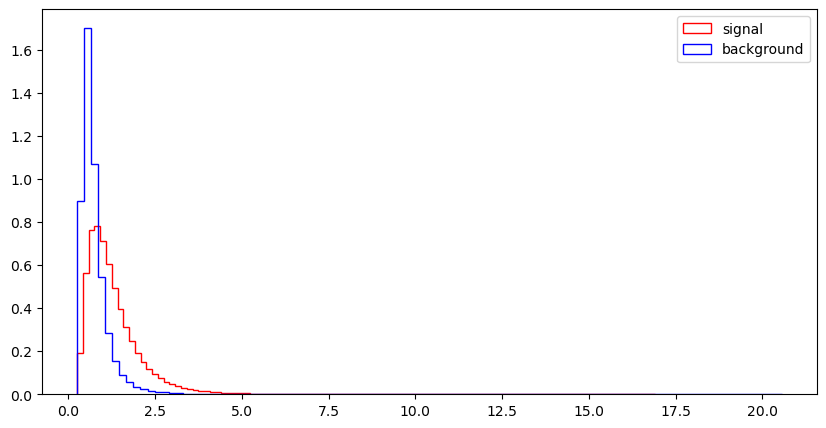

l_1_eta


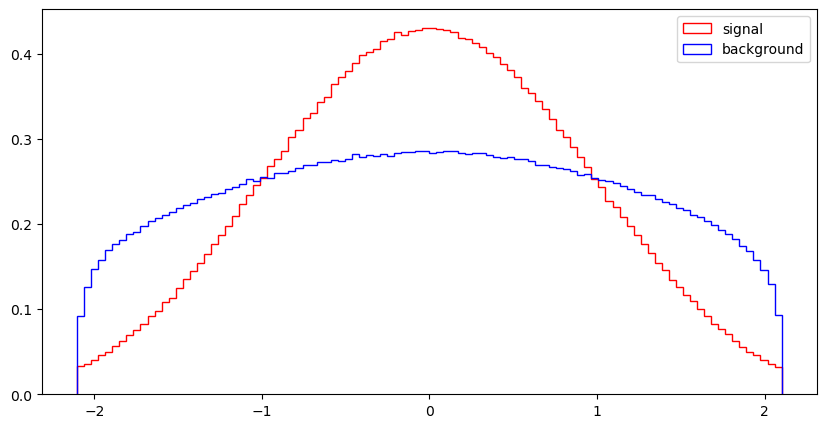

l_1_phi


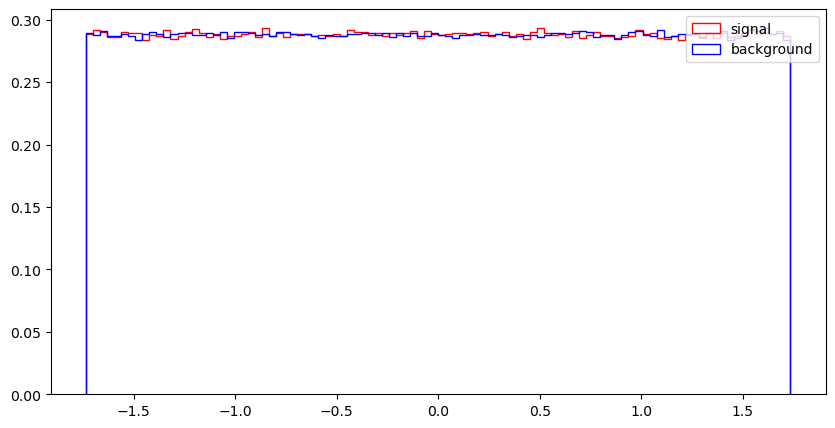

l_2_pT


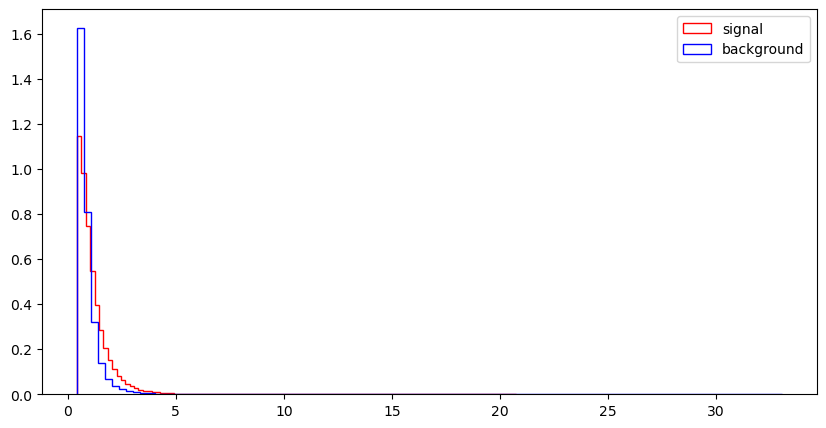

l_2_eta


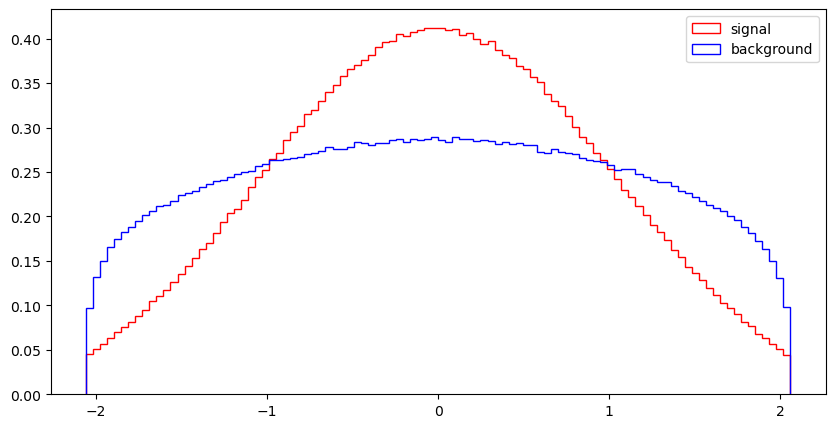

l_2_phi


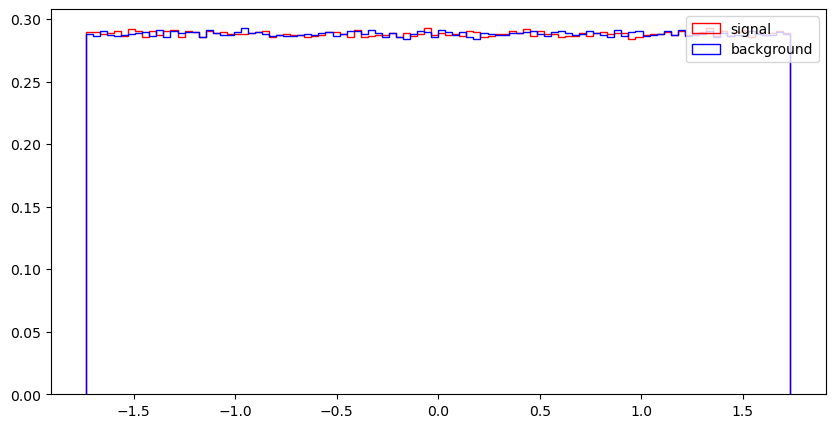

MET


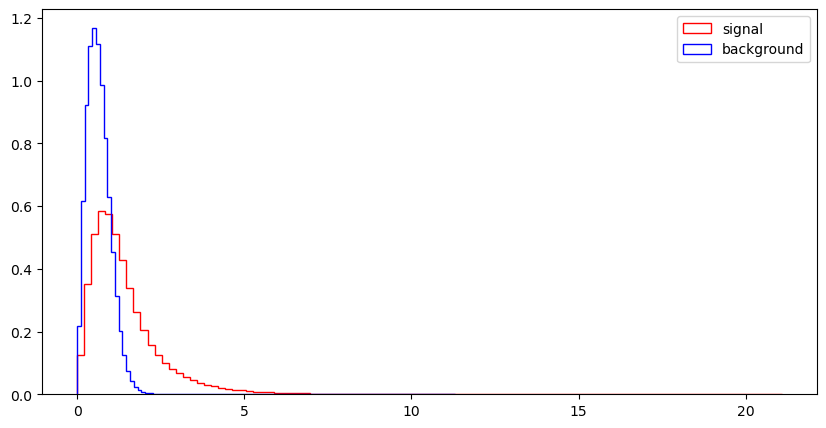

MET_phi


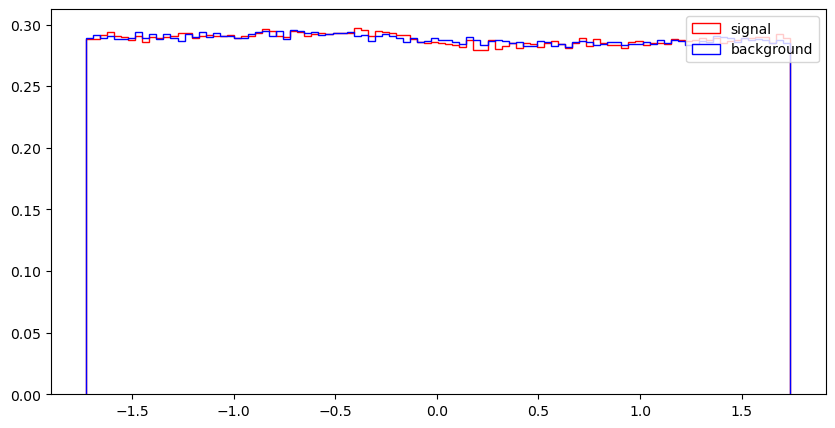

MET_rel


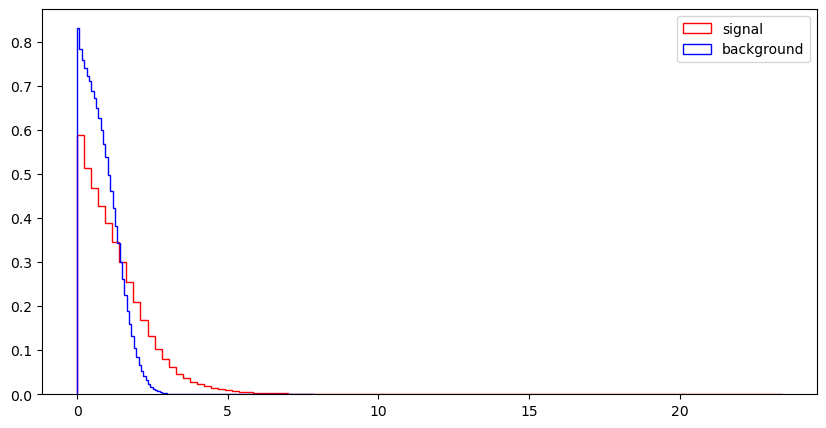

axial_MET


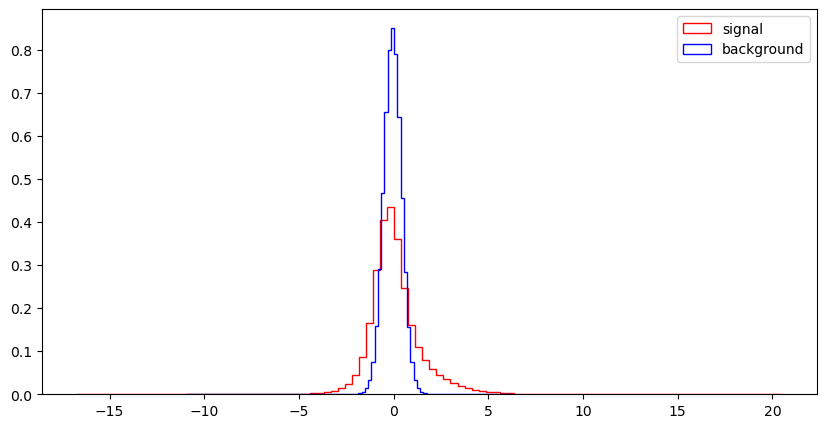

M_R


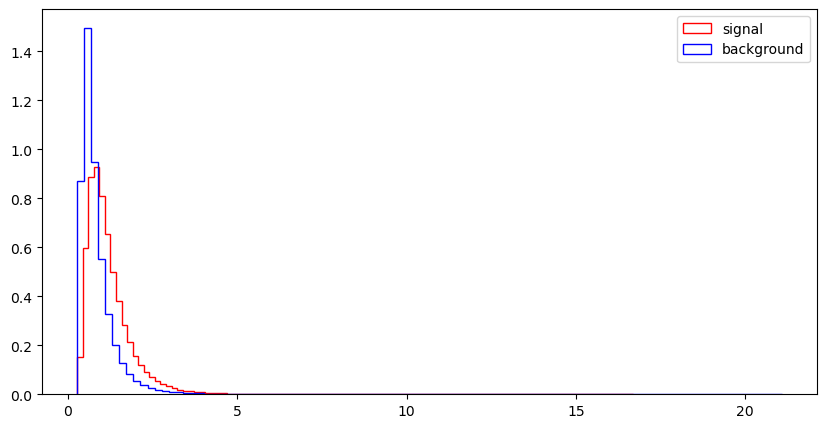

M_TR_2


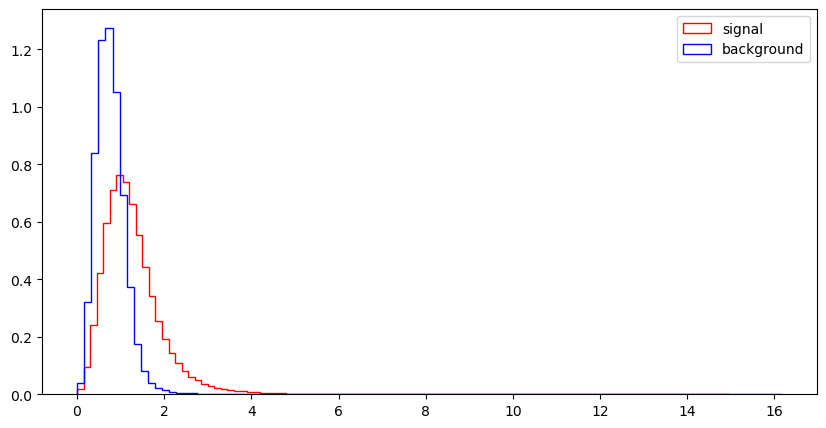

R


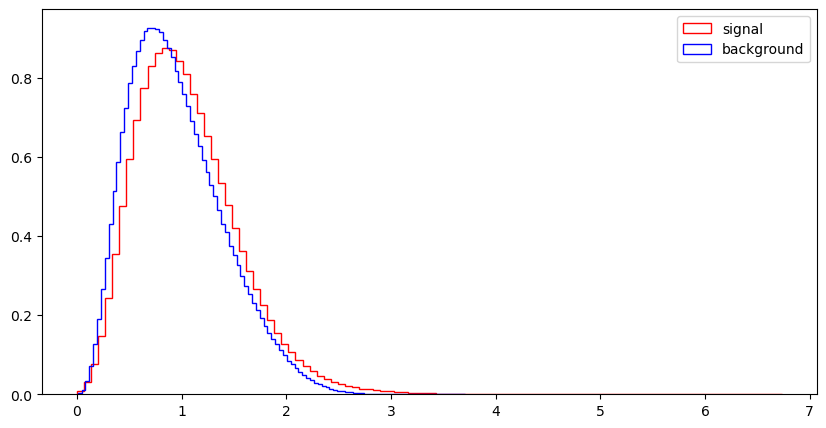

MT2


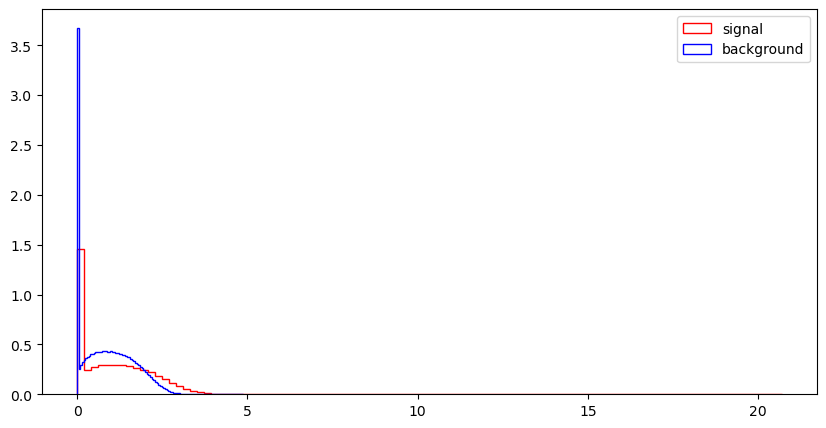

S_R


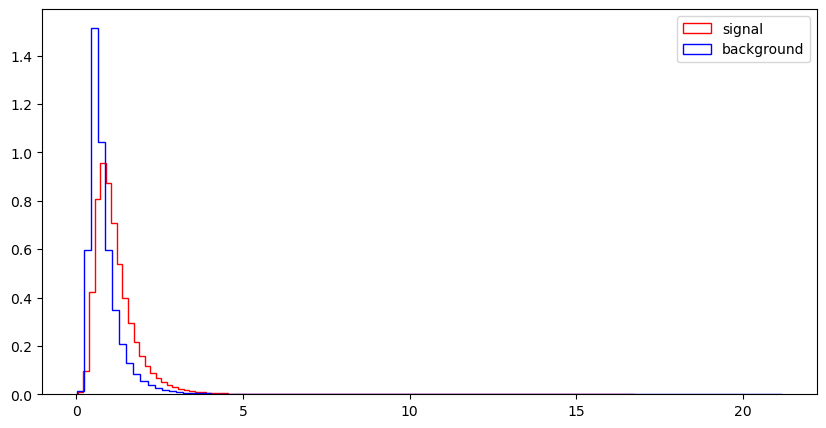

M_Delta_R


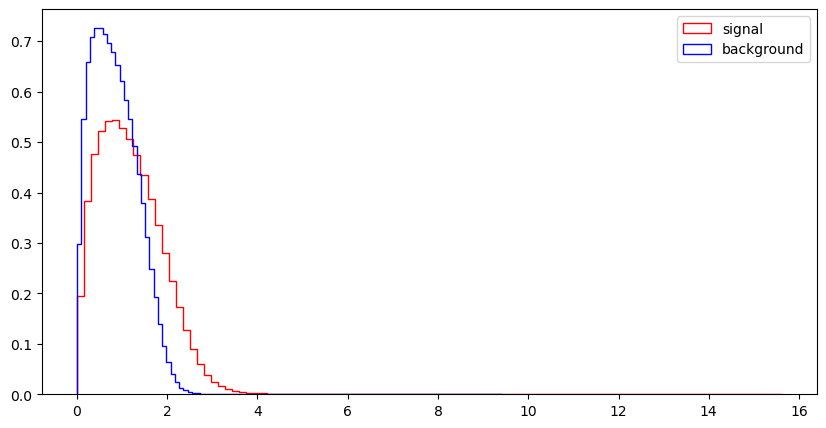

dPhi_r_b


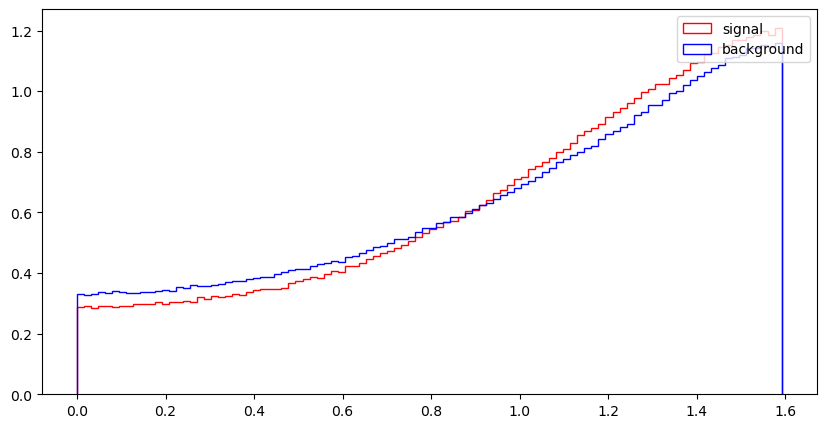

cos_theta_r1


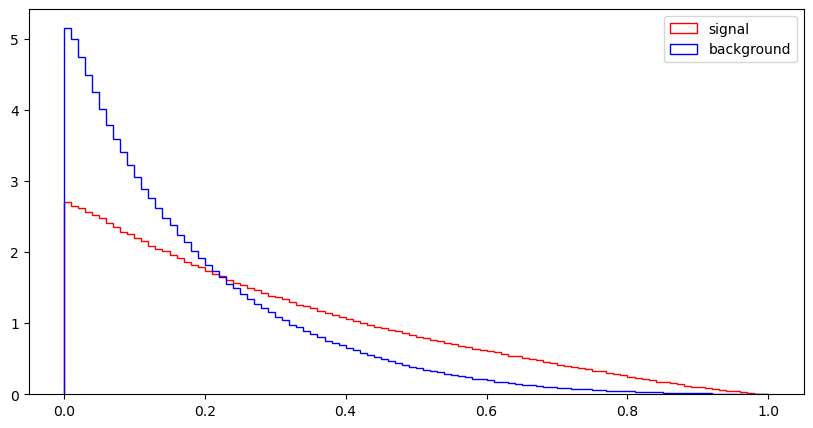

In [16]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

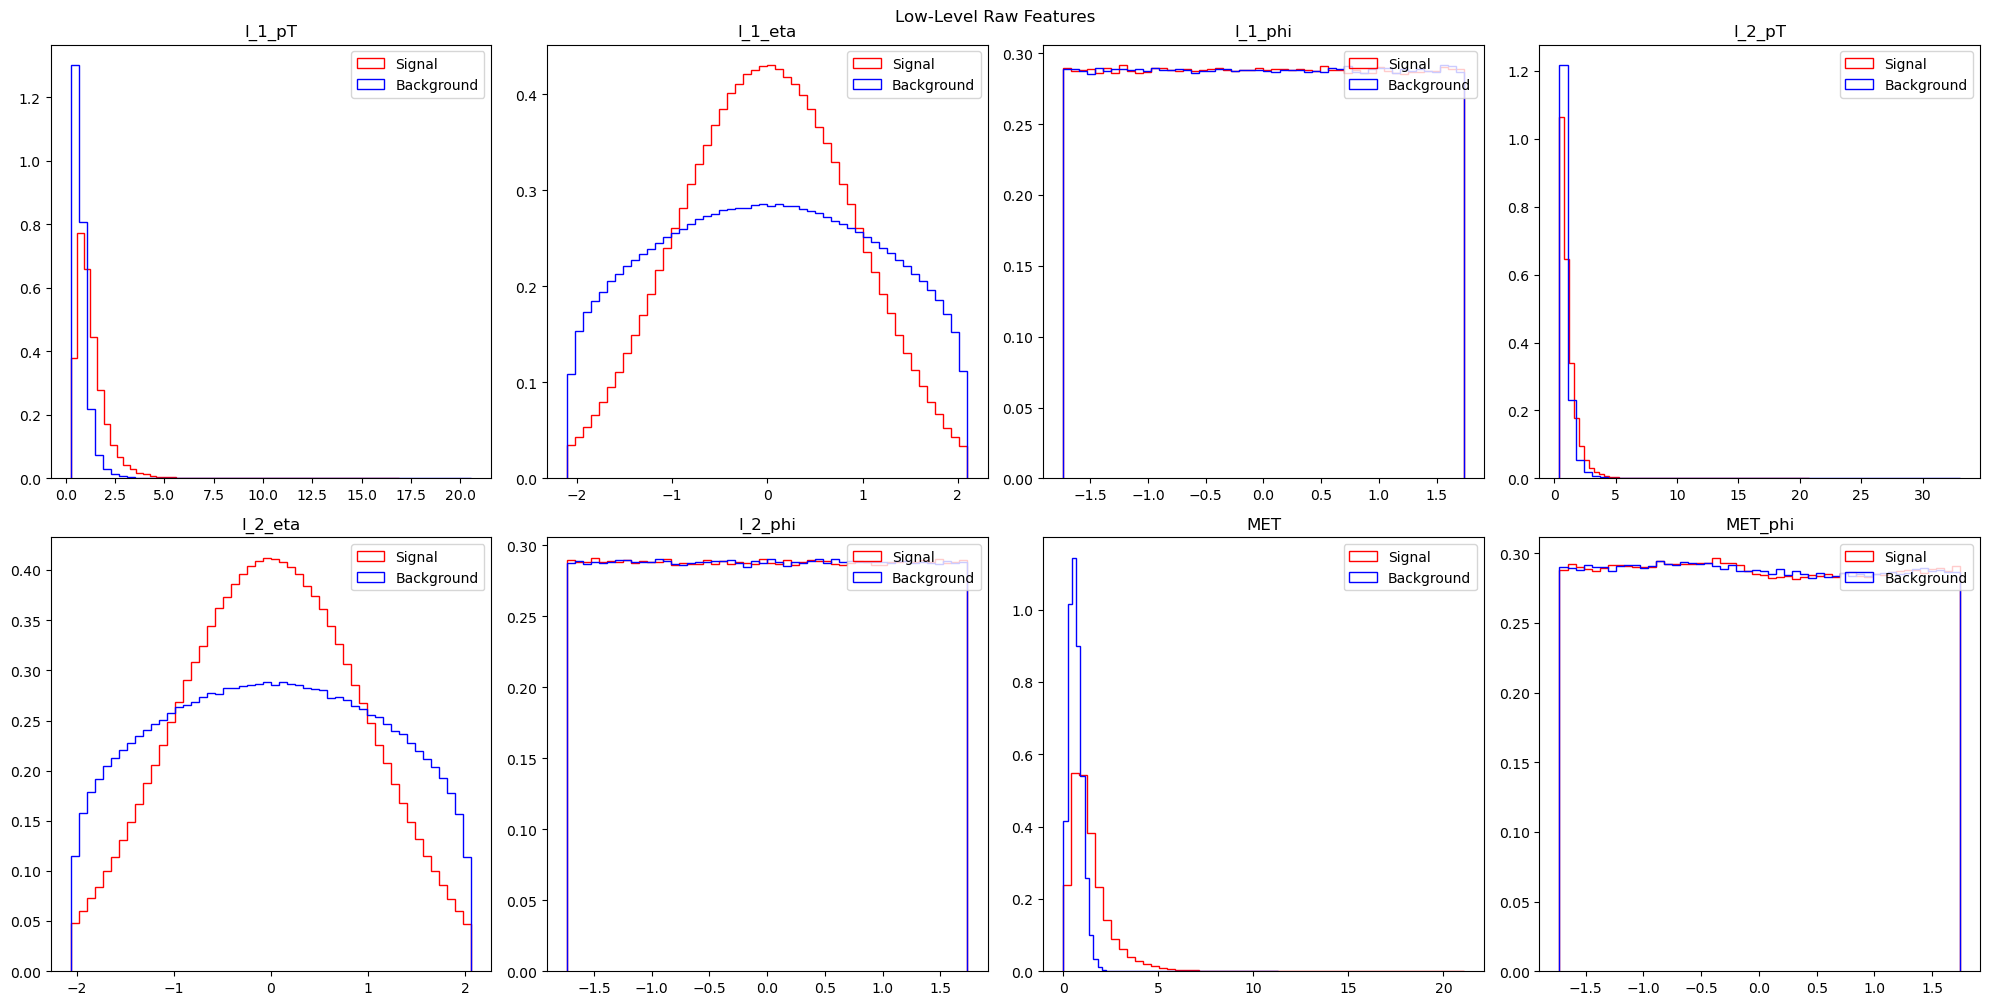

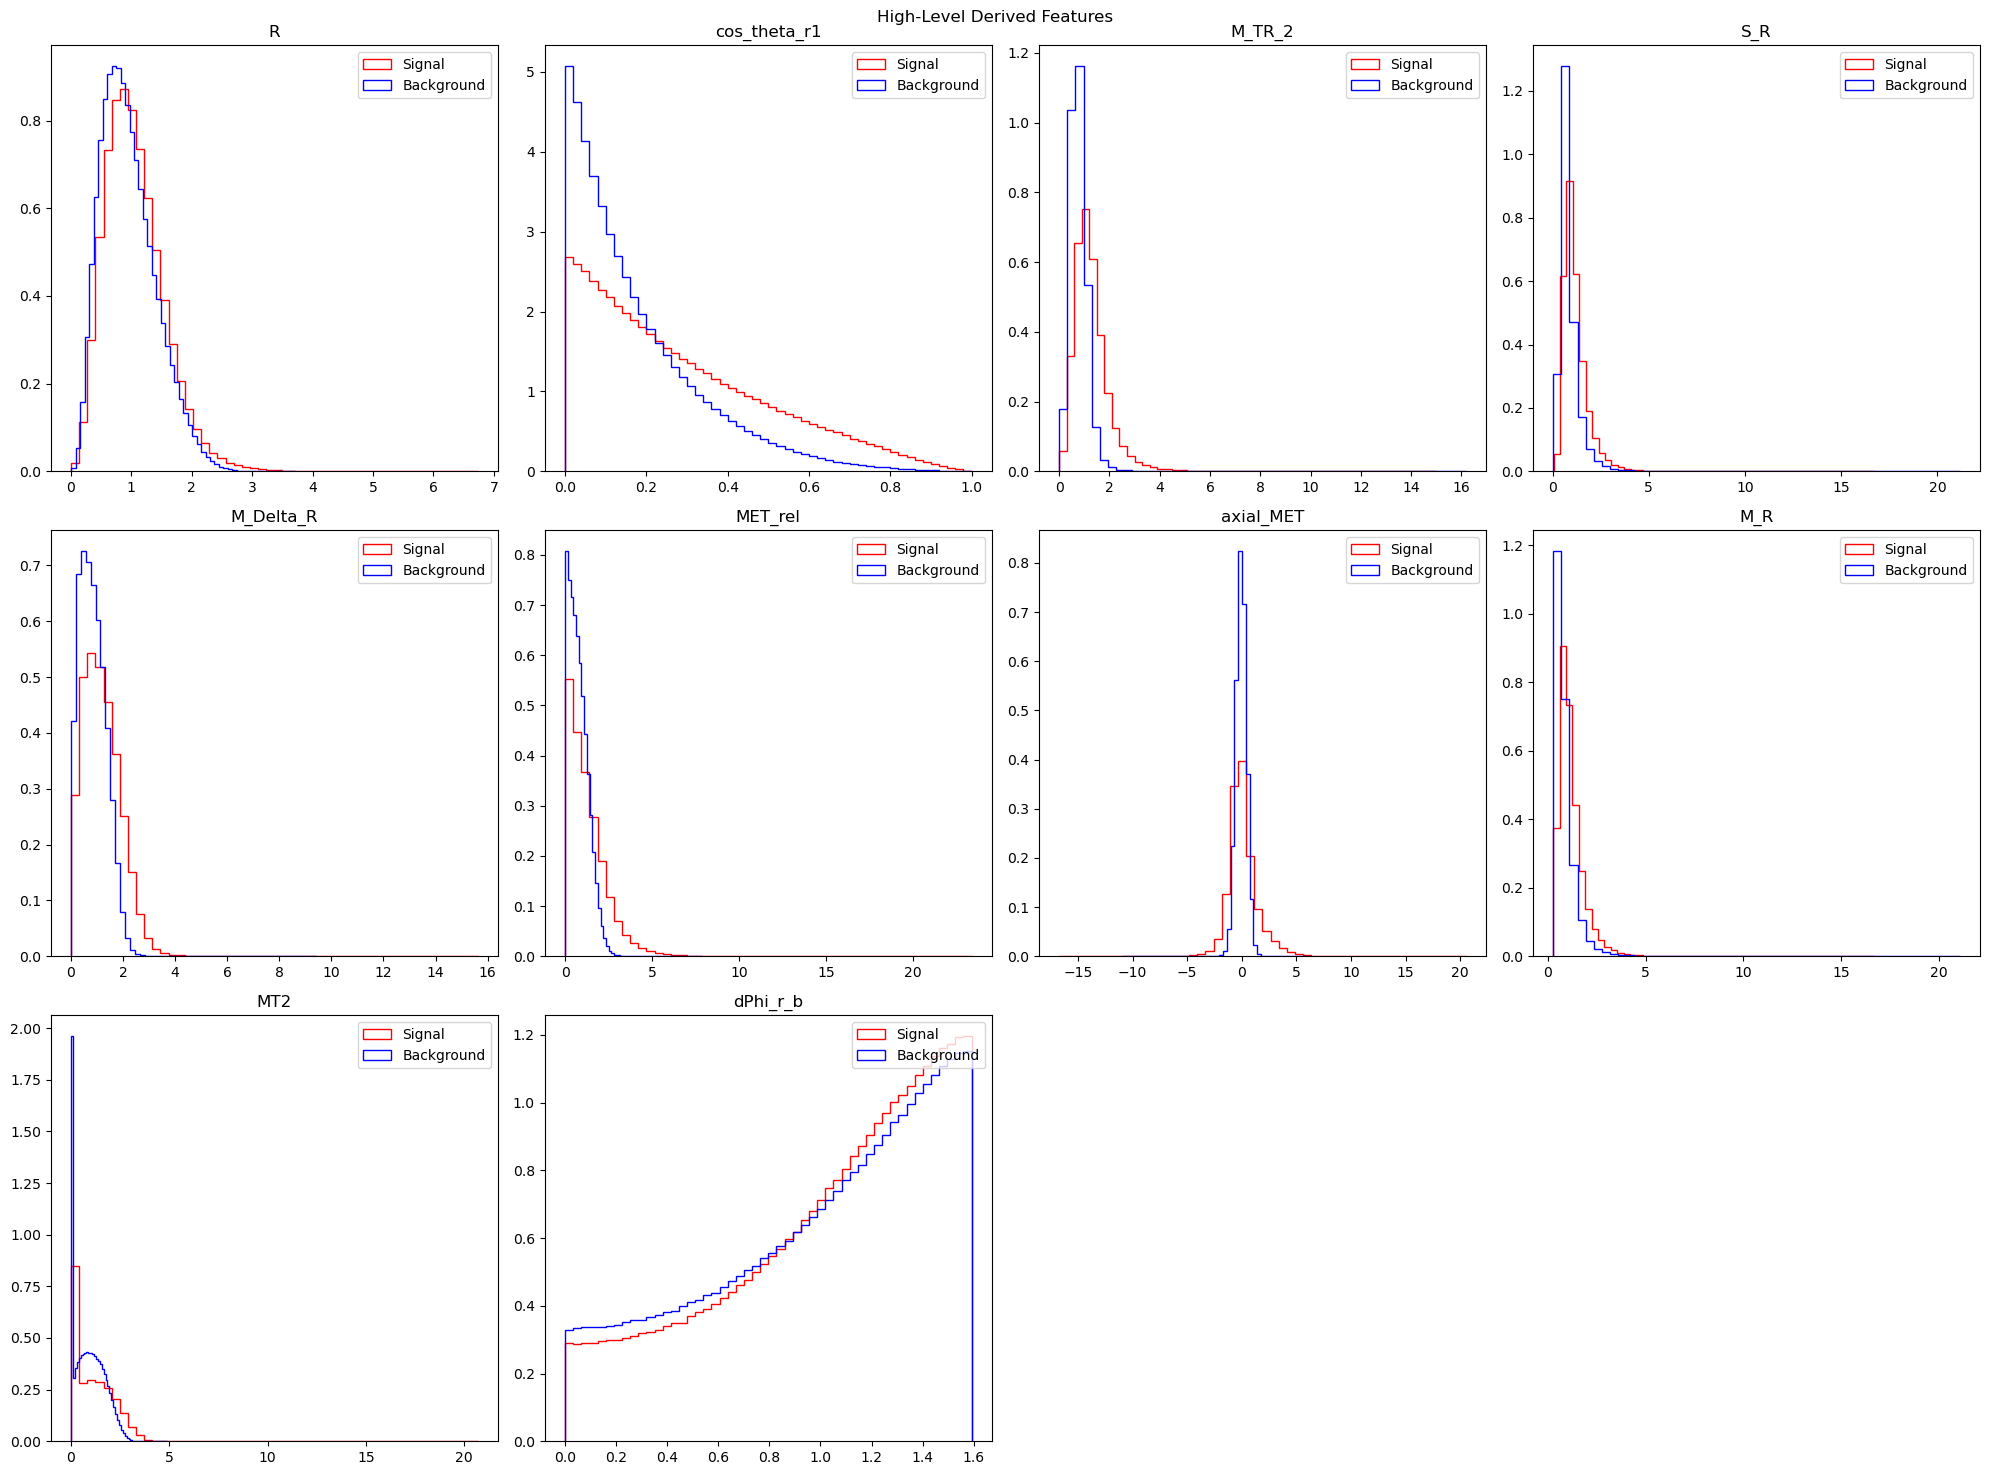

In [19]:
import matplotlib.pyplot as plt

def plot_histograms(data_sig, data_bkg, variables, title):
    n = len(variables)
    rows = (n // 4) + 1
    plt.figure(figsize=(20, 5 * rows))
    
    for i, var in enumerate(variables):
        plt.subplot(rows, 4, i + 1)
        plt.hist(data_sig[var], bins=50, histtype='step', color='red', label='Signal', density=True)
        plt.hist(data_bkg[var], bins=50, histtype='step', color='blue', label='Background', density=True)
        plt.title(var)
        plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_histograms(df_sig, df_bkg, RawNames, "Low-Level Raw Features")
plot_histograms(df_sig, df_bkg, FeatureNames, "High-Level Derived Features")

#### The code loops through each feature and draws two overlapping "step" histograms. We use density=True because the total number of signal and background events is different, so we want to compare their relative shapes.

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

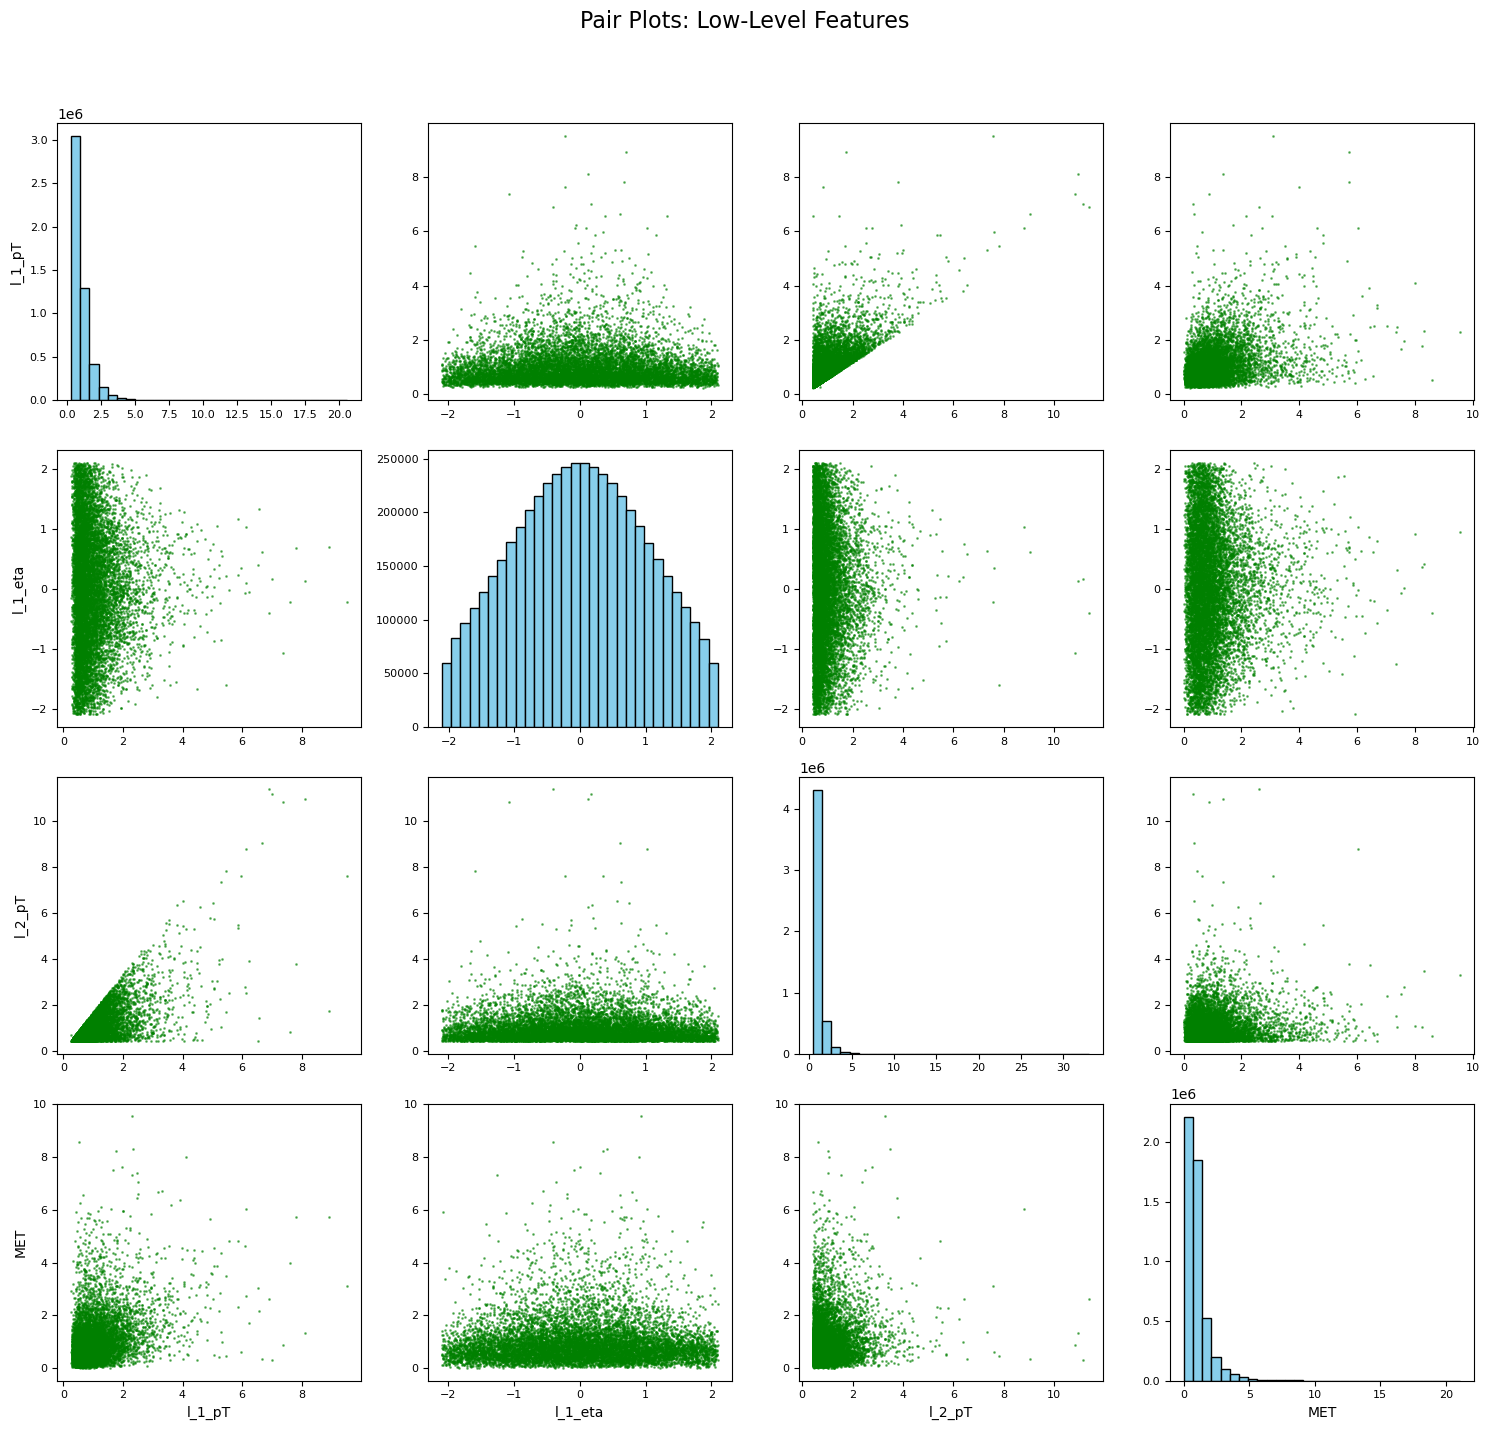

In [26]:
#Part a

import matplotlib.pyplot as plt
import numpy as np

def create_pair_plots(df, columns, title):
    n = len(columns)
    fig, axes = plt.subplots(n, n, figsize=(15, 15))
    fig.suptitle(title, fontsize=16)

    for i in range(n):
        for j in range(n):
            var_x = columns[j]
            var_y = columns[i]
            
            if i == j:
                axes[i, j].hist(df[var_x], bins=30, color='skyblue', edgecolor='black')
            else:
                axes[i, j].scatter(df[var_x][::500], df[var_y][::500], s=1, alpha=0.5, color='green')
            
            if i == n - 1: axes[i, j].set_xlabel(var_x)
            if j == 0: axes[i, j].set_ylabel(var_y)
            axes[i, j].tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

raw_subset = ["l_1_pT", "l_1_eta", "l_2_pT", "MET"]
create_pair_plots(df, raw_subset, "Pair Plots: Low-Level Features")

#The function loops through the column list twice to create an $N \times N$ grid. If the row index equals the column index, it draws a histogram; otherwise, it draws a scatter plot to show how the two variables move together.

Dataset loaded successfully.


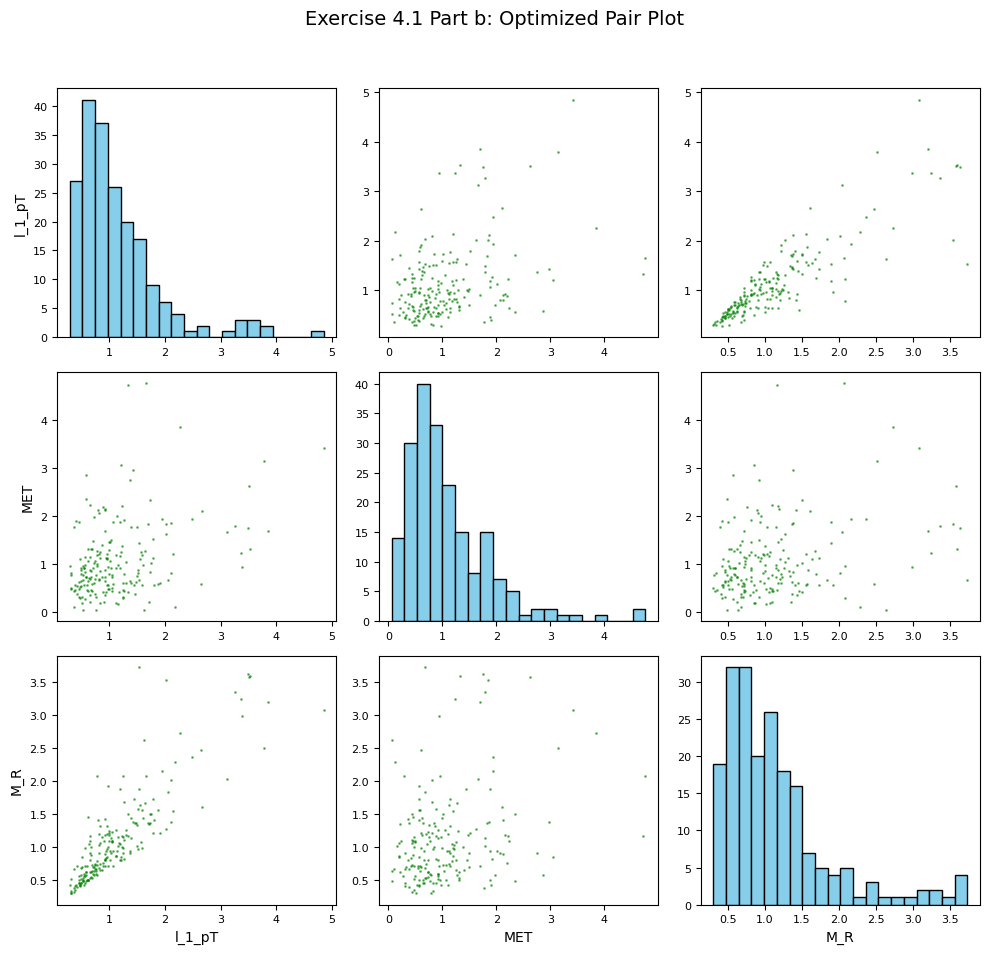

In [29]:
#Part b

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", 
            "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", 
            "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

try:
    df = pd.read_csv("SUSY.csv", header=None, names=VarNames, nrows=10000)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: SUSY.csv not found. Please ensure the file is in your folder.")

def optimized_pair_plot(df, columns):
    n = len(columns)
    fig, axes = plt.subplots(n, n, figsize=(10, 10))
    fig.suptitle("Exercise 4.1 Part b: Optimized Pair Plot", fontsize=14)
    
    for i in range(n):
        for j in range(n):
            x_data = df[columns[j]][::50]
            y_data = df[columns[i]][::50]
            
            if i == j:
                axes[i, j].hist(x_data, bins=20, color='skyblue', edgecolor='black')
            else:
                axes[i, j].scatter(x_data, y_data, s=1, alpha=0.5, color='green')
            
            if i == n - 1: axes[i, j].set_xlabel(columns[j])
            if j == 0: axes[i, j].set_ylabel(columns[i])
            axes[i, j].tick_params(labelsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if 'df' in locals():
    test_features = ["l_1_pT", "MET", "M_R"]
    optimized_pair_plot(df, test_features)
    
# Data Slicing: We use [::50] to plot only every 50th data point, which speeds up the rendering process while still showing the overall distribution trends.

# Explicit Display: Adding plt.show() at the end of the function ensures that the Matplotlib backend forces the graphical window to open and display the grid.

# Speed Proposal: A faster alternative for massive datasets like SUSY.csv is using plt.hist2d, which calculates a density map once rather than drawing thousands of individual scatter points.

### Part C

The physics motivated quantities, formed by taking the raw 4-vectors and then taking different combinations, the so-called High-Level features, are reliably more separable than the so-called Low-Level raw detector measurements. Particularly, MET (Missing Transverse Energy) is a primary measure to determine Supersymmetry since the final state in the SUSY decay chain will usually be unobservable to detect, resulting in an enormously larger MET monitor in the signal events than the basic background mechanism does. Also, such quantities as the stransverse mass (MT2) and the MR exhibit characteristic distributions with observable peaks or edges of signal events; in such quantities either nonexistent background distributions or displaced to display significant differences. Although raw variables such as lepton transverse momenta (pT) can be used to gain some information, they typically show a substantial overlap between signal and background, but the correlations in high-level mass variables such as the MDeltaR and MTR2 can be used to classify the data much better.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [3]:
# Part b

import numpy as np
import pandas as pd

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", 
            "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", 
            "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv("SUSY.csv", header=None, names=VarNames, nrows=500000)

RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = [v for v in VarNames[1:] if v not in RawNames]

high_level_data = df[FeatureNames].values.T
cov_matrix_high = np.cov(high_level_data)
corr_matrix_high = np.corrcoef(high_level_data)

## np.cov calculates how much variables change together, while np.corrcoef scales that value between -1 and 1 to show the strength of the relationship.

In [5]:
# Part c

from tabulate import tabulate
from IPython.display import HTML, display

def display_matrix(matrix, headers, title):
    print(f"\n{title}")
    formatted_table = []
    for i, row in enumerate(matrix):
        formatted_table.append([headers[i]] + list(np.round(row, 3)))
    
    display(HTML(tabulate(formatted_table, tablefmt='html', headers=["Var"] + headers)))

display_matrix(corr_matrix_high, FeatureNames, "Correlation Matrix: High-Level Features")

# We round the numbers to 3 decimal places so the table isn't messy. The HTML function makes the table look like a real grid in your browser.


Correlation Matrix: High-Level Features


Var,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272
M_R,0.078,0.027,1,0.577,-0.383,-0.068,0.981,0.189,-0.106,-0.116
M_TR_2,0.584,-0.317,0.577,1,0.38,0.379,0.635,0.668,0.229,0.451
R,0.595,-0.383,-0.383,0.38,1,0.574,-0.287,0.564,0.424,0.627
MT2,0.535,-0.535,-0.068,0.379,0.574,1,-0.021,0.809,0.056,0.264
S_R,0.15,-0.067,0.981,0.635,-0.287,-0.021,1,0.249,-0.013,-0.085
M_Delta_R,0.748,-0.373,0.189,0.668,0.564,0.809,0.249,1,0.155,0.319
dPhi_r_b,0.378,-0.057,-0.106,0.229,0.424,0.056,-0.013,0.155,1,0.106
cos_theta_r1,0.316,-0.272,-0.116,0.451,0.627,0.264,-0.085,0.319,0.106,1


In [6]:
# Part d

def perform_matrix_analysis(data_frame, columns, label):
    # Step B: Compute matrices
    data = data_frame[columns].values.T
    corr = np.corrcoef(data)
    
    table_rows = []
    for i, name in enumerate(columns):
        table_rows.append([name] + list(np.round(corr[i], 3)))
    
    print(f"--- {label} Correlation Analysis ---")
    display(HTML(tabulate(table_rows, tablefmt='html', headers=[""] + columns)))

perform_matrix_analysis(df, RawNames, "Low-Level (Raw)")

#This combines everything into one tool. You give it the table (df) and the columns you want to check, and it prints the final formatted correlation grid.

--- Low-Level (Raw) Correlation Analysis ---


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


Hint: Example code for embedding a `tabulate` table into a notebook:

In [7]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [8]:
# 5.1 

import pandas as pd

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", 
            "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", 
            "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv("SUSY.csv", header=None, names=VarNames, nrows=500000)
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

criteria = {}
for var in VarNames[1:]:
    if df_sig[var].mean() > df_bkg[var].mean():
        criteria[var] = f"{var} > x_c"
    else:
        criteria[var] = f"{var} < x_c"

print("Optimal Selection Criteria (Example):")
print(f"MET: {criteria['MET']}")
print(f"l_1_eta: {criteria['l_1_eta']}")

# We compare the average value of each variable for signal and background events. If the signal average is higher, the rule x > x_c is typically better for isolating it; if lower, we use x < x_c.

Optimal Selection Criteria (Example):
MET: MET > x_c
l_1_eta: l_1_eta > x_c


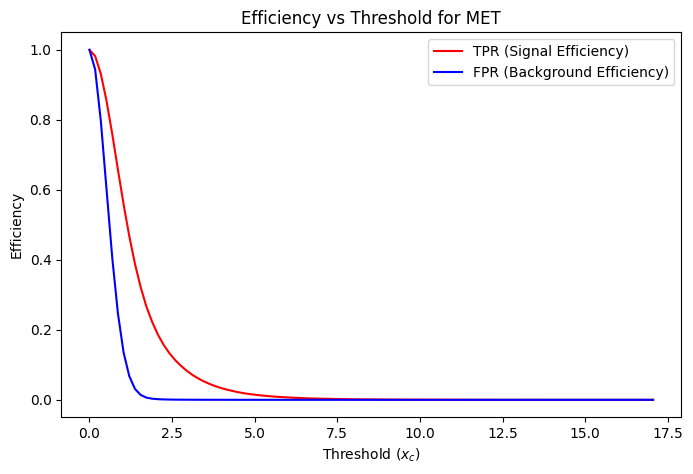

In [10]:
# 5.2

import matplotlib.pyplot as plt
import numpy as np

def plot_efficiency(df_sig, df_bkg, var):
    thresholds = np.linspace(df[var].min(), df[var].max(), 100)
    tpr_list = []
    fpr_list = []
    
    for x_c in thresholds:
        tpr = np.sum(df_sig[var] > x_c) / len(df_sig)
        fpr = np.sum(df_bkg[var] > x_c) / len(df_bkg)
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, tpr_list, label="TPR (Signal Efficiency)", color='red')
    plt.plot(thresholds, fpr_list, label="FPR (Background Efficiency)", color='blue')
    plt.title(f"Efficiency vs Threshold for {var}")
    plt.xlabel("Threshold ($x_c$)")
    plt.ylabel("Efficiency")
    plt.legend()
    plt.show()

plot_efficiency(df_sig, df_bkg, "MET")

# This code sweeps through many possible values of x_c and counts how much signal and background "pass" the filter. The resulting plot shows the trade-off: as you make the rule stricter, you lose background (good) but also lose some signal (bad).

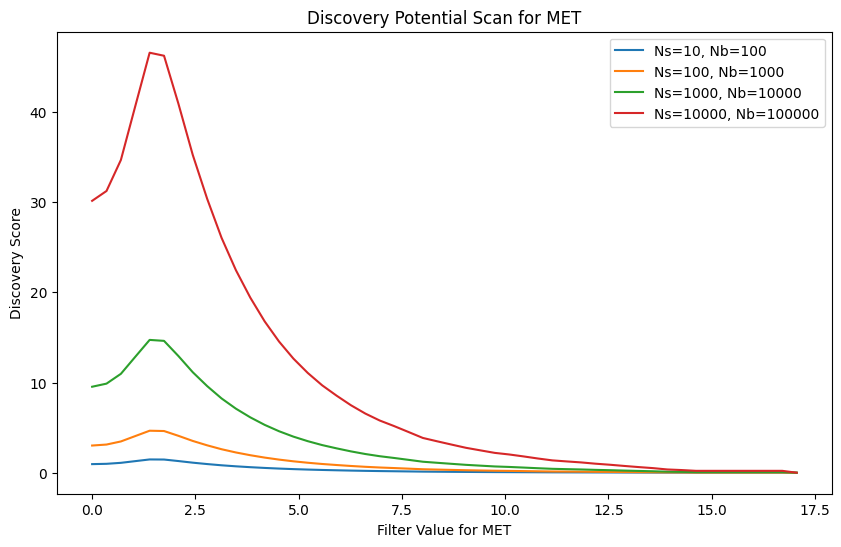

In [14]:
# 5.3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", 
            "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", 
            "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv("SUSY.csv", header=None, names=VarNames, nrows=500000)
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

def run_significance_analysis(var_name, sig_df, bkg_df):
    scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]
    thresholds = np.linspace(df[var_name].min(), df[var_name].max(), 50)
    
    plt.figure(figsize=(10, 6))
    
    for ns, nb in scenarios:
        sig_scores = []
        for x_c in thresholds:
            tpr = np.sum(sig_df[var_name] > x_c) / len(sig_df)
            fpr = np.sum(bkg_df[var_name] > x_c) / len(bkg_df)
            
            ns_final = tpr * ns
            nb_final = fpr * nb
            score = ns_final / np.sqrt(ns_final + nb_final + 1e-10)
            sig_scores.append(score)
        
        plt.plot(thresholds, sig_scores, label=f"Ns={ns}, Nb={nb}")
        
    plt.title(f"Discovery Potential Scan for {var_name}")
    plt.xlabel(f"Filter Value for {var_name}")
    plt.ylabel("Discovery Score")
    plt.legend()
    plt.show()

run_significance_analysis("MET", df_sig, df_bkg)

#The primary goal of this script is to determine the most effective threshold for a specific variable to distinguish the signal from the background. We calculate the percentage of data passing each filter and scale those figures to match the expected event counts for different research scenarios. The resulting plot identifies the optimal threshold at the highest peak, representing the point where our ability to discover new physics is at its maximum.
#In this implementation, we load a subset of the data and split it into signal and background groups to ensure statistical accuracy for the significance curves. We then test multiple threshold values across four different data scenarios to measure how the discovery potential changes with different sample sizes. By calculating a discovery score for each point and including a constant to prevent errors, we can visualize the trade-off between signal retention and background removal.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 